# Rhabdoid cohorts clinical plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## SJD data

In [3]:
sjd_df = pd.read_csv('clinical_data/SJD_clinical_data_patient.tsv',sep='\t')
sjd_df = sjd_df[0:20]
exclude_pts = ['2','10','16','20']
sjd_df = sjd_df[~sjd_df['PATIENT_ID'].isin(exclude_pts)]
print(len(sjd_df))
sjd_df

16


,PATIENT_ID,GENDER,TUMOR_TYPE,TAB_DIAGNOSIS,TREATMENT,TAB_TTMT_START_DATE,TAB_TTMT_END_DATE,STATUS (Deceased/Alive),SAMPLE_AVAILABILITY,Diagnosis,Primary tumor,Metastasis (at debut),Site of relapse,Unnamed: 13
0,1,Male,MRT,8.29,mP6 protocol + surgery + radiotherapy,8.32,8.67,Alive,Diagnosis. Second look surgery (post-chemo),MRT,Pelvis,No,NaN,NaN
2,3,Male,MRT,4.75,St Jude protocol (incomplete) + surgery + radi...,4.79,5.05,Deceased,"Diagnosis, Relapse post chemo (Lung)",RTK,Kidney,No,"lung, lymph nodes",NaN
3,4,Female,MRT,0.02,No treatment,NaN,NaN,Deceased,"Diagnosis, Necropsy (no treatment)",MRT,Skin and soft tissue,lymph nodes,NaN,NaN
4,5,Male,MRT,13.50,St Jude protocol (incomplete),13.58,13.63,Deceased,"Diagnosis, Diagnosis, Necropsy (post chemo)",MRT,Paraspinal,"lymph nodes, lung",PD,NaN
5,6,Male,ATRT,1.52,Boston protocol,1.56,NaN,Deceased,"Post chemo, Necropsy (post chemo)",MRT,CNS (cervical),lung,PD,NaN
6,7,Male,ATRT,1.98,surgery + COG,1.98,2.19,Alive,Recurrence (post chemo),ATRT,Brain,No,PD,NaN
7,8,Male,ATRT,3.00,surgery + Dana Farber + radiotherapy,3.06,3.4,Alive,Diagnosis,ATRT,Brain,No,NaN,NaN
8,9,Female,MRT,0.48,mP6 protocol + surgery,0.45,0.52,Deceased,"Diagnosis, Second look surgery (post chemo)",MRT,Liver,No,PD,NaN
10,11,Female,ATRT,5.57,Dana Farber + surgery + radiotherapy + retinoi...,5.56,9.2,Deceased,Diagnosis,ATRT,Brain,CSF,NaN,NaN
11,12,Male,MRT,0.62,mP6 + surgery + radiotherapy + tamoxifen + ret...,0.17,NaN,Deceased,"Progression (post chemo), Progression (post ch...",MRT,Armpit,lung,"PD (LUNG, LIVER, KIDNEYS)",NaN


## TARGET data

In [4]:
empty_cell = "'--"
empty_col = [empty_cell] * 69

In [5]:
target_df = pd.read_csv('clinical_data/TARGET_clinical_data.tsv',sep='\t')
cols = list(target_df)
info_cols = []
for col in cols:
    column = target_df[col].tolist()
    if column != empty_col:
        info_cols.append(col)
target_df = target_df[info_cols]
target_df

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
0,01444de8-344b-566e-a461-8ef82b0796d8,TARGET-52-PAKPEW,TARGET-RT,153,not hispanic or latino,male,white,Dead,950,Stage IV,153.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2001
1,0f9e1dc9-5003-5628-8c3f-5e599a13c90d,TARGET-52-PAUEKW,TARGET-RT,'--,not hispanic or latino,female,other,Alive,5386,Stage III,625.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2011
2,105d2431-78e7-5e34-b620-0b9d4fd9d1a3,TARGET-52-PASGGN,TARGET-RT,112,not hispanic or latino,male,white,Dead,130,Stage IV,112.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
3,122eba47-a308-5c80-a332-06b37f12cc3a,TARGET-52-PAJLRA,TARGET-RT,16,Unknown,female,white,Dead,3,Stage III,16.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1996
4,153c5c30-41d5-5369-873f-d086ead699a4,TARGET-52-PASVDP,TARGET-RT,'--,not hispanic or latino,female,white,Alive,141,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,ea300498-806d-56cf-9cca-adb64f869e7b,TARGET-52-PARUGK,TARGET-RT,'--,hispanic or latino,male,white,Alive,220,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
65,ead9a4f1-e7d2-5341-93a0-a67267c28728,TARGET-52-PASAMZ,TARGET-RT,'--,hispanic or latino,female,white,Alive,3027,Stage I,1746.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2008
66,ee33dcef-f61c-5ee0-9c65-a4eb475a2406,TARGET-52-PAVDPR,TARGET-RT,'--,not hispanic or latino,male,white,Unknown,749,Stage IV,'--,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2012
67,ef42d20f-5f3e-58c6-9d52-0a2aa48a162c,TARGET-52-PAJNFZ,TARGET-RT,48,Unknown,male,black or african american,Dead,592,Stage IV,48.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1999


In [6]:
# get patients with bam
target_samples_list = []
for n in range(1,8):
    df1 = pd.read_csv('variant_calling/target_cohort/sarek_results/input_fastq_batch'+str(n)+'.csv')
    p = list(df1['patient'].unique())
    target_samples_list = target_samples_list + p
print(len(target_samples_list))

target_df['PATIENT'] = target_df['case_submitter_id'].str.split('-',expand=True)[2]
target_df['AGE_DIAGNOSIS'] = target_df['age_at_diagnosis'] / 365
target_df = target_df[target_df['PATIENT'].isin(target_samples_list)]

target_df[['PATIENT','AGE_DIAGNOSIS']]

56


,PATIENT,AGE_DIAGNOSIS
1,PAUEKW,14.756164
4,PASVDP,0.386301
5,PAREWI,0.841096
6,PAUNPA,2.843836
7,PATXKA,0.279452
8,PAJLWM,0.794521
9,PATDVL,0.400000
11,PAVYDM,0.463014
12,PABKLN,1.095890
13,PAJMRB,1.482192


## ST JUDE data

In [7]:
import json

In [8]:
stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))
stjude_tumors = [stjude_dict[pt]['tumor1'] for pt in stjude_dict.keys()]
bad_quality_samples = ['SJBT032047_D1','SJBT033133_D3']
xenograft = ['SJMRT063832_X1']
no_age_data = ['SJMRT014754_D1']
exclude_samples =  bad_quality_samples + xenograft+ no_age_data
stjude_tumors = [t for t in stjude_tumors if t not in exclude_samples]
print(len(stjude_tumors))
stjude_tumors

16


['SJMRT015723_D1',
 'SJBT030128_D1',
 'SJBT030255_D1',
 'SJBT030581_D1',
 'SJBT030707_D2',
 'SJBT030896_D1',
 'SJBT030997_D1',
 'SJBT031235_D1',
 'SJBT031605_D1',
 'SJBT031948_D2',
 'SJBT032346_D1',
 'SJBT032393_D1',
 'SJBT032417_D2',
 'SJBT033236_D2',
 'SJBT034089_D1',
 'SJBT034110_D2']

In [9]:
stjude_df = pd.read_csv('clinical_data/StJude_clinical_data.txt',sep='\t')
df1 = pd.read_csv('variant_calling/stjude_cohort/sarek_results/input_fastq.csv')
pts = df1['patient'].unique()
stjude_df = stjude_df[stjude_df['subject_name'].isin(pts)]
stjude_df = stjude_df[stjude_df['sample_name'].isin(stjude_tumors)]
stjude_df = stjude_df[stjude_df['sample_type'].isin(['Diagnosis','Other','Metastasis'])]
stjude_df = stjude_df[stjude_df['file_path'].str.endswith('bam')]
stjude_df = stjude_df[['subject_name','sample_name','sj_long_disease_name',
       'attr_age_at_diagnosis', 'attr_diagnosis', 'attr_sex', 'attr_ethnicity',
       'attr_race','attr_subtype_biomarkers',
       'sj_associated_diagnoses',
       'attr_diagnosis_group', 'sj_access_unit',
       'sj_diseases', 'sj_datasets',
       'sj_disease_hierarchy_code', 'sj_disease_hierarchy_name'       ]]
stjude_df

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
3,SJ030255,SJBT030255_D1,Atypical Teratoid/Rhabdoid Tumors,2.42,Atypical Teratoid Rhabdoid Tumor,Male,Not Hispanic Or Latino,Asian,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
4,SJ030128,SJBT030128_D1,Atypical Teratoid/Rhabdoid Tumors,1.17,Atypical Teratoid Rhabdoid Tumor,Female,Not Hispanic Or Latino,White,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
12,SJ030581,SJBT030581_D1,Atypical Teratoid/Rhabdoid Tumors,10.25,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Male,Not Hispanic Or Latino,Black Or African American,NaN,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
14,SJ030997,SJBT030997_D1,Atypical Teratoid/Rhabdoid Tumors,0.50,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Female,Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
35,SJ030896,SJBT030896_D1,Atypical Teratoid/Rhabdoid Tumors,2.75,"ATYPICAL TERATOID RHABDOID TUMOR, LEFT FRONTAL...",Male,Not Hispanic Or Latino,Other,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
41,SJ030707,SJBT030707_D2,Atypical Teratoid/Rhabdoid Tumors,1.58,"ATYPICAL TERATOID RHABDOID TUMOR, POSTERIOR FOSSA",Male,Not Hispanic Or Latino,Black Or African American,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
45,SJ031235,SJBT031235_D1,Atypical Teratoid/Rhabdoid Tumors,0.67,"ATYPICAL TERATOID/RHABDOID TUMOR, FORTH VENTRICLE",Female,Not Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
46,SJ015723,SJMRT015723_D1,"Rhabdoid Cancer, Kidney",1.00,Not Available,Male,Not Available,Not Available,Not Available,"Rhabdoid Cancer, Kidney (MRT)",Solid Tumor,PCGP,MRT,Childhood Solid Tumor Network (CSTN),ST|KID|MRT,"Solid Tumor|Kidney|Rhabdoid Cancer, Kidney"
65,SJ031605,SJBT031605_D1,Atypical Teratoid/Rhabdoid Tumors,2.25,"ATYPICAL TERATOID RHABDOID TUMOR, FRONTOTEMPOR...",Male,Not Hispanic Or Latino,Declined To Respond,NF1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
75,SJ032393,SJBT032393_D1,Atypical Teratoid/Rhabdoid Tumors,14.00,Malignant neoplasm of overlapping sites of brain,Female,Not Hispanic Or Latino,White,SMARCB1 LOSS,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...


## PMC case

In [10]:
pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))
pmc_loc_dict = {'OMEN':'Omentum',
                'DIAF':'Diaphragm',
                'LN':'Lymph node',
                'LNMETA':'Lymph node'}

In [11]:
pmc_df = pd.DataFrame([])
for t in (t for t in pmc_dict['PMC01'].keys() if t not in ['normal','normal2']):
    tumor_id = pmc_dict['PMC01'][t]
    pmc_case_dict = {'PATIENT':'PMC01',
                     'SEX':'Female',
                     'TUMOR_TYPE':'MRT',
                     'COHORT':'PMC',
                    'SAMPLE_ID':tumor_id,
                    'SAMPLE_TYPE':'post ttmt',
                    'AGE_DIAGNOSIS':2.5,
                    'PRY_TUMOR_SITE':'Soft tissue',
                    'SAMPLE_LOCATION': pmc_loc_dict[tumor_id],
                    'PATIENT':'PMC01',
                    'SAMPLE':'PMC01_t'+t[-1]}
    pmc_df = pd.concat([pmc_df,pd.DataFrame([pmc_case_dict])])
pmc_df

,PATIENT,SEX,TUMOR_TYPE,COHORT,SAMPLE_ID,SAMPLE_TYPE,AGE_DIAGNOSIS,PRY_TUMOR_SITE,SAMPLE_LOCATION,SAMPLE
0,PMC01,Female,MRT,PMC,DIAF,post ttmt,2.5,Soft tissue,Diaphragm,PMC01_t1
0,PMC01,Female,MRT,PMC,OMEN,post ttmt,2.5,Soft tissue,Omentum,PMC01_t2
0,PMC01,Female,MRT,PMC,LN,post ttmt,2.5,Soft tissue,Lymph node,PMC01_t3
0,PMC01,Female,MRT,PMC,LNMETA,post ttmt,2.5,Soft tissue,Lymph node,PMC01_t4


## CONCAT tables

In [12]:
sjd_df.columns

Index(['PATIENT_ID', 'GENDER', 'TUMOR_TYPE', 'TAB_DIAGNOSIS', 'TREATMENT',
       'TAB_TTMT_START_DATE', 'TAB_TTMT_END_DATE', 'STATUS (Deceased/Alive)',
       'SAMPLE_AVAILABILITY', 'Diagnosis', 'Primary tumor',
       'Metastasis (at debut)', 'Site of relapse', 'Unnamed: 13'],
      dtype='object')

In [13]:
cols = ['PATIENT','AGE_DIAGNOSIS','SEX','TUMOR_TYPE','PRY_TUMOR_SITE','COHORT']

In [14]:
sjd_df['PATIENT'] = sjd_df['PATIENT_ID'].replace('14*','14')
sjd_df['PATIENT'] = 'pt'+sjd_df['PATIENT']
sjd_df['TUMOR_TYPE'] = sjd_df['TUMOR_TYPE'].replace('SMARCA4mut','ATRT')
sjd_df['PRY_TUMOR_SITE'] = sjd_df['Primary tumor'].replace('Skin and soft tissue','Soft tissue').replace('CNS (cervical)','Brain').replace('Laterocervical soft tissue','Soft tissue').replace('Soft tissue (multiple tumor masses)','Soft tissue')
sjd_df['SEX'] = sjd_df['GENDER']
sjd_df['AGE_DIAGNOSIS'] = sjd_df['TAB_DIAGNOSIS']
sjd_df['COHORT'] = 'SJD'
sjd_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,pt1,8.29,Male,MRT,Pelvis,SJD
2,pt3,4.75,Male,MRT,Kidney,SJD
3,pt4,0.02,Female,MRT,Soft tissue,SJD
4,pt5,13.50,Male,MRT,Paraspinal,SJD
5,pt6,1.52,Male,ATRT,Brain,SJD
6,pt7,1.98,Male,ATRT,Brain,SJD
7,pt8,3.00,Male,ATRT,Brain,SJD
8,pt9,0.48,Female,MRT,Liver,SJD
10,pt11,5.57,Female,ATRT,Brain,SJD
11,pt12,0.62,Male,MRT,Armpit,SJD


In [15]:
target_df.columns

Index(['case_id', 'case_submitter_id', 'project_id', 'days_to_death',
       'ethnicity', 'gender', 'race', 'vital_status', 'age_at_diagnosis',
       'cog_renal_stage', 'days_to_last_follow_up',
       'last_known_disease_status', 'morphology', 'primary_diagnosis',
       'progression_or_recurrence', 'site_of_resection_or_biopsy',
       'tissue_or_organ_of_origin', 'tumor_grade', 'year_of_diagnosis',
       'PATIENT', 'AGE_DIAGNOSIS'],
      dtype='object')

In [16]:
target_df['SEX'] = target_df['gender'].replace('female','Female')
target_df['SEX'] = target_df['SEX'].replace('male','Male')
target_df['TUMOR_TYPE'] = target_df['primary_diagnosis'].replace('Malignant rhabdoid tumor','MRT')
target_df['PRY_TUMOR_SITE'] = target_df['site_of_resection_or_biopsy'].replace('Kidney, NOS','Kidney')
target_df['COHORT'] = 'TARGET'
target_df[cols]

/tmp/ipykernel_1162515/16774340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['gender'].replace('female','Female')
/tmp/ipykernel_1162515/16774340.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['SEX'].replace('male','Male')
/tmp/ipykernel_1162515/16774340.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
1,PAUEKW,14.756164,Female,MRT,Kidney,TARGET
4,PASVDP,0.386301,Female,MRT,External upper lip,TARGET
5,PAREWI,0.841096,Female,MRT,Kidney,TARGET
6,PAUNPA,2.843836,Male,MRT,Kidney,TARGET
7,PATXKA,0.279452,Female,MRT,Liver,TARGET
8,PAJLWM,0.794521,Male,MRT,Kidney,TARGET
9,PATDVL,0.400000,Male,MRT,Kidney,TARGET
11,PAVYDM,0.463014,Female,MRT,Kidney,TARGET
12,PABKLN,1.095890,Male,MRT,Kidney,TARGET
13,PAJMRB,1.482192,Female,MRT,Kidney,TARGET


In [17]:
stjude_df.columns

Index(['subject_name', 'sample_name', 'sj_long_disease_name',
       'attr_age_at_diagnosis', 'attr_diagnosis', 'attr_sex', 'attr_ethnicity',
       'attr_race', 'attr_subtype_biomarkers', 'sj_associated_diagnoses',
       'attr_diagnosis_group', 'sj_access_unit', 'sj_diseases', 'sj_datasets',
       'sj_disease_hierarchy_code', 'sj_disease_hierarchy_name'],
      dtype='object')

In [18]:
stjude_df['PATIENT'] = stjude_df['subject_name']
stjude_df['AGE_DIAGNOSIS'] = stjude_df['attr_age_at_diagnosis']
stjude_df['SEX'] = stjude_df['attr_sex']
stjude_df['TUMOR_TYPE'] = stjude_df['sj_associated_diagnoses'].str.split('(',expand=True)[1].str.split(')',expand=True)[0]
stjude_df['PRY_TUMOR_SITE'] = stjude_df['TUMOR_TYPE'].replace('ATRT','Brain').replace('MRT','Kidney')
stjude_df['COHORT'] = 'StJude'
stjude_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
3,SJ030255,2.42,Male,ATRT,Brain,StJude
4,SJ030128,1.17,Female,ATRT,Brain,StJude
12,SJ030581,10.25,Male,ATRT,Brain,StJude
14,SJ030997,0.50,Female,ATRT,Brain,StJude
35,SJ030896,2.75,Male,ATRT,Brain,StJude
41,SJ030707,1.58,Male,ATRT,Brain,StJude
45,SJ031235,0.67,Female,ATRT,Brain,StJude
46,SJ015723,1.00,Male,MRT,Kidney,StJude
65,SJ031605,2.25,Male,ATRT,Brain,StJude
75,SJ032393,14.00,Female,ATRT,Brain,StJude


In [19]:
clinical_df = pd.concat([sjd_df[cols],target_df[cols],stjude_df[cols],pmc_df[cols].drop_duplicates()])
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,pt1,8.29,Male,MRT,Pelvis,SJD
2,pt3,4.75,Male,MRT,Kidney,SJD
3,pt4,0.02,Female,MRT,Soft tissue,SJD
4,pt5,13.5,Male,MRT,Paraspinal,SJD
5,pt6,1.52,Male,ATRT,Brain,SJD
...,...,...,...,...,...,...
91,SJ032417,0.17,Female,ATRT,Brain,StJude
103,SJ033236,0.75,Female,ATRT,Brain,StJude
124,SJ034089,0.42,Male,ATRT,Brain,StJude
126,SJ034110,0.67,Male,ATRT,Brain,StJude


In [20]:
clinical_df['AGE_DIAGNOSIS'] = clinical_df['AGE_DIAGNOSIS'].astype(float)
clinical_df = clinical_df.sort_values('AGE_DIAGNOSIS',ascending=True)

In [21]:
new_pt_ids = [ 'PT'+f"{number:02d}" for number in range(1,len(clinical_df)+1)]

In [22]:
clinical_df['PATIENT2'] = new_pt_ids
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2
17,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01
3,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02
12,pt13,0.060000,Male,MRT,Soft tissue,SJD,PT03
33,PAUDPV,0.147945,Female,MRT,Kidney,TARGET,PT04
91,SJ032417,0.170000,Female,ATRT,Brain,StJude,PT05
...,...,...,...,...,...,...,...
12,SJ030581,10.250000,Male,ATRT,Brain,StJude,PT85
4,pt5,13.500000,Male,MRT,Paraspinal,SJD,PT86
75,SJ032393,14.000000,Female,ATRT,Brain,StJude,PT87
1,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88


In [28]:
clinical_df.to_csv('clinical_data/Clinical_Data_SJD_TARGET_StJude_PMC.tsv',index=None,sep='\t')

In [29]:
sample_final_ids_dict = dict(zip(clinical_df['PATIENT'], clinical_df['PATIENT2']))
sample_final_ids_dict

{'pt18': 'PT01',
 'pt4': 'PT02',
 'pt13': 'PT03',
 'PAUDPV': 'PT04',
 'SJ032417': 'PT05',
 'PAJNER': 'PT06',
 'PASWZZ': 'PT07',
 'PAVYKD': 'PT08',
 'PATXKA': 'PT09',
 'PARECB': 'PT10',
 'PASVDP': 'PT11',
 'PAJMBW': 'PT12',
 'PATDVL': 'PT13',
 'PARGRN': 'PT14',
 'SJ034089': 'PT15',
 'PAVYDM': 'PT16',
 'PASABD': 'PT17',
 'PAEHIP': 'PT18',
 'pt9': 'PT19',
 'SJ030997': 'PT20',
 'PASYNF': 'PT21',
 'PARRCL': 'PT22',
 'PARUGK': 'PT23',
 'pt12': 'PT24',
 'PAWFWK': 'PT25',
 'PAUHAZ': 'PT26',
 'SJ031235': 'PT27',
 'SJ034110': 'PT28',
 'PARTKH': 'PT29',
 'PASADZ': 'PT30',
 'SJ033236': 'PT31',
 'PAUCGJ': 'PT32',
 'PASXNA': 'PT33',
 'PAJLWM': 'PT34',
 'PASRHU': 'PT35',
 'PAREWI': 'PT36',
 'PASZYE': 'PT37',
 'PASDLA': 'PT38',
 'PATAFT': 'PT39',
 'PAJNFP': 'PT40',
 'PASCDH': 'PT41',
 'PARPFY': 'PT42',
 'SJ015723': 'PT43',
 'PADWRZ': 'PT44',
 'PATFZZ': 'PT45',
 'PABKLN': 'PT46',
 'pt19': 'PT47',
 'SJ030128': 'PT48',
 'PAUGYZ': 'PT49',
 'PARZBI': 'PT50',
 'PAKLYZ': 'PT51',
 'PAJMRB': 'PT52',
 'pt6': 'P

In [30]:
sample_final_ids_dict['pt6']

'PT53'

In [31]:
clinical_df[['PATIENT','PATIENT2']][clinical_df['PATIENT']=='PAKLYZ']

,PATIENT,PATIENT2
43,PAKLYZ,PT51


In [32]:
with open('sample_ids/sample_ids_final.json','w') as f:
    json.dump(sample_final_ids_dict,f)

## Load table with mutation data

In [33]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
0,pt1,tumor1,AX4912_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,False,del / del,NaN,NaN,NaN
1,pt1,tumor2,AX4937_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,del / del,NaN,NaN,NaN
2,pt3,tumor1,AX4914_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
3,pt3,tumor2,AX4915_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
4,pt4,tumor1,AX4916_vs_AX4896,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,True,del / CNLOH,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,SJ063832,tumor1,SJMRT063832_X1_vs_SJMRT063832_G1,St Jude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,False,del / del,NaN,NaN,Excluded due to xenograft sample
112,PMC01,tumor1,DIAF_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,1.980902,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
113,PMC01,tumor2,OMEN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.208627,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
114,PMC01,tumor3,LN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.012602,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN


In [34]:
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]

In [35]:
smarcb1_df.groupby('SAMPLE').count()

,PATIENT,TUMOR,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
SAMPLE,,,,,,,,,,,,,,,,,,,,,
AX4912_vs_AX4894,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4914_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4915_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4916_vs_AX4896,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4918_vs_AX4897,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJBT032417_D2_vs_SJBT032417_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0
SJBT033236_D2_vs_SJBT033236_G1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
SJBT034089_D1_vs_SJBT034089_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0


In [36]:
smarcb1_df.groupby(['PATIENT']).count()

,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
PATIENT,,,,,,,,,,,,,,,,,,,,,
PABKLN,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
PADWRZ,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,0,0,0
PADYZI,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,1,2,2,0,0,0
PAEHIP,1,1,1,1,0,0,0,0,0,1,...,0,1,1,1,1,1,1,0,0,0
PAJLWM,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pt5,2,2,2,2,0,0,0,0,0,2,...,2,0,0,0,2,2,2,0,0,0
pt6,2,2,2,2,2,2,2,2,2,2,...,2,0,0,0,2,2,2,0,0,0
pt7,1,1,1,1,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,0,0


In [37]:
smarcb1_df[['COHORT','PATIENT']].drop_duplicates().groupby(['COHORT']).count()

,PATIENT
COHORT,
PMC,1
SJD,16
St Jude,16
TARGET,56


In [38]:
clinical_df[['COHORT','PATIENT']].groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [39]:
smarcb1_df.columns

Index(['PATIENT', 'TUMOR', 'SAMPLE', 'COHORT', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples'],
      dtype='object')

In [40]:
# smarcb1_df = smarcb1_df[~smarcb1_df['SMARCB1 status'].str.contains('MYCN')]
smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
smarcb1_df['origin_a1'] = smarcb1_df['allele1'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['origin_a2'] = smarcb1_df['allele2'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['germline'] = smarcb1_df['SMARCB1 status'].str.contains('germline')
smarcb1_df['CNLOH'] = smarcb1_df['SMARCB1 status'].str.contains('CNLOH')
smarcb1_df['COHORT'] = smarcb1_df['COHORT'].replace('St Jude','StJude')
smarcb1_df[['PATIENT','SMARCB1 status','allele1','allele2','origin_a1','origin_a2','germline']].drop_duplicates()

/tmp/ipykernel_1162515/2682153593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
/tmp/ipykernel_1162515/2682153593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
/tmp/ipykernel_1162515/2682153593.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

,PATIENT,SMARCB1 status,allele1,allele2,origin_a1,origin_a2,germline
0,pt1,del / del,del,del,somatic,somatic,False
2,pt3,R40* / exon1-del,R40*,exon1-del,somatic,somatic,False
4,pt4,del / CNLOH,del,CNLOH,somatic,somatic,False
6,pt5,del / del,del,del,somatic,somatic,False
8,pt6,S66SX / CNLOH,S66SX,CNLOH,somatic,somatic,False
...,...,...,...,...,...,...,...
106,SJ032417,del / CNLOH,del,CNLOH,somatic,somatic,False
108,SJ033236,splice variant / chrom loss,splice variant,chrom loss,somatic,somatic,False
109,SJ034089,del / del,del,del,somatic,somatic,False
110,SJ034110,I99ILDX (exon3-ins8) / del,I99ILDX (exon3-ins8),del,somatic,somatic,False


## Merge tables

In [41]:
clinical_df['PATIENT'] = clinical_df['PATIENT'].apply(lambda x: 'pt'+x if x in [str(n) for n in range(0,20)] else x)
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2
17,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01
3,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02
12,pt13,0.060000,Male,MRT,Soft tissue,SJD,PT03
33,PAUDPV,0.147945,Female,MRT,Kidney,TARGET,PT04
91,SJ032417,0.170000,Female,ATRT,Brain,StJude,PT05
...,...,...,...,...,...,...,...
12,SJ030581,10.250000,Male,ATRT,Brain,StJude,PT85
4,pt5,13.500000,Male,MRT,Paraspinal,SJD,PT86
75,SJ032393,14.000000,Female,ATRT,Brain,StJude,PT87
1,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88


In [42]:
smarcb1_df[smarcb1_df['COHORT']=='StJude']

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
91,SJ015723,tumor1,SJMRT015723_D1_vs_SJMRT015723_G1,StJude,SMARCB1,truncating,frameshift_variant,-184-185VLX,chr22:23803347:->GTGCTGGT,TRUE,...,False,-184-185VLX (exon5-ins8) / exon6-del,NaN,23815319-23820410,NaN,-184-185VLX (exon5-ins8),exon6-del,somatic,somatic,False
92,SJ030128,tumor1,SJBT030128_D1_vs_SJBT030128_G1,StJude,SMARCB1,NaN,del / del,NaN,NaN,NaN,...,False,del / chrom loss,NaN,NaN,NaN,del,chrom loss,somatic,somatic,False
93,SJ030255,tumor1,SJBT030255_D1_vs_SJBT030255_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,False,del / chrom loss,NaN,NaN,NaN,del,chrom loss,somatic,somatic,False
94,SJ030581,tumor1,SJBT030581_D1_vs_SJBT030581_G1,StJude,SMARCB1,other,"splice_region_variant,synonymous_variant",S329,chr22:23833572:C>T,TRUE,...,False,del / del,NaN,NaN,NaN,del,del,somatic,somatic,False
95,SJ030581,tumor1,SJBT030581_D1_vs_SJBT030581_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,False,del / del,NaN,NaN,NaN,del,del,somatic,somatic,False
96,SJ030707,tumor1,SJBT030707_D2_vs_SJBT030707_G1,StJude,SMARCB1,truncating,frameshift_variant,A382X,chr22:23834167:C>-,TRUE,...,False,A382X / chrom loss,NaN,NaN,NaN,A382X,chrom loss,somatic,somatic,False
97,SJ030896,tumor1,SJBT030896_D1_vs_SJBT030896_G1,StJude,SMARCB1,truncating,stop_gained,W206*,chr22:23803411:G>A,TRUE,...,False,W206* / chrom loss,NaN,NaN,NaN,W206*,chrom loss,somatic,somatic,False
98,SJ030997,tumor1,SJBT030997_D1_vs_SJBT030997_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,True,exon6-del germline / CNLOH,23814125-23818084,NaN,NaN,exon6-del germline,CNLOH,germline,somatic,True
99,SJ031235,tumor1,SJBT031235_D1_vs_SJBT031235_G1,StJude,SMARCB1,truncating,frameshift_variant,F164X,chr22:23801073:C>-,TRUE,...,True,F164X germline / CNLOH,NaN,NaN,NaN,F164X germline,CNLOH,germline,somatic,True
100,SJ031605,tumor1,SJBT031605_D1_vs_SJBT031605_G1,StJude,SMARCB1,truncating,frameshift_variant,S258SDX,chr22:23816914:->CAGA,TRUE,...,False,S258SDX and L303X / chrom loss,NaN,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False


In [43]:
merged_df = pd.merge(clinical_df,smarcb1_df,how='outer',indicator=True)

In [44]:
merged_df.groupby('_merge').count()

/tmp/ipykernel_1162515/1673711432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby('_merge').count()


,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
_merge,,,,,,,,,,,,,,,,,,,,,
left_only,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
right_only,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
both,107,107,107,107,107,107,107,107,107,107,...,107,107,17,3,0,107,107,107,107,107


In [45]:
merged_df[['PATIENT','COHORT']].drop_duplicates().groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [46]:
merged_df[['SAMPLE','COHORT']].drop_duplicates().groupby('COHORT').count()

,SAMPLE
COHORT,
PMC,4
SJD,22
StJude,16
TARGET,56


In [47]:
merged_df.columns

Index(['PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT', 'PATIENT2', 'TUMOR', 'SAMPLE', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples', 'allele1', 'allele2', 'origin_a1', 'origin_a2',
       'germline', '_merge'],
      dtype='object')

In [48]:
merged_df['AGE_DIAGNOSIS'] = merged_df['AGE_DIAGNOSIS'].astype(float)
merged_df.sort_values('AGE_DIAGNOSIS')

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge
0,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
2,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
1,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
3,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
4,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02,tumor1,AX4916_vs_AX4896,SMARCB1,...,del / CNLOH,NaN,NaN,NaN,del,CNLOH,somatic,somatic,False,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
103,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
105,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
104,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both


In [49]:
def define_mut_type (x):
    
    if '*' in x or 'fs' in x:
        mut_type = 'frameshift'
    elif 'X' in x:
        mut_type = 'snv-nonsense'
    elif 'splice' in x:
        mut_type = 'splice variant'
    elif 'exon' in x:
        mut_type = 'exon deletion'
    elif 'del' in x:
        mut_type = 'deep deletion'
    elif 'chrom loss' in x:
        mut_type = 'chrom loss'
    elif 'CNLOH' in x:
        mut_type = 'CN-LOH'
    elif 'amp' in x:
        mut_type = 'MYCNamp (NBL)'
    else:
        mut_type = 'MYCNamp (NBL)'
    
    return mut_type

merged_df['mut_type_a1'] = merged_df['allele1'].apply(lambda x: define_mut_type(x))
merged_df['mut_type_a2'] = merged_df['allele2'].apply(lambda x: define_mut_type(x))
merged_df[['allele1','allele2','mut_type_a1','mut_type_a2']].groupby(['mut_type_a1','mut_type_a2']).count()

allele1  allele2
mut_type_a1    mut_type_a2                    
MYCNamp (NBL)  MYCNamp (NBL)        1        1
deep deletion  CN-LOH               7        7
               chrom loss           3        3
               deep deletion       33       33
               frameshift           1        1
               snv-nonsense         2        2
exon deletion  CN-LOH              13       13
               deep deletion        4        4
frameshift     CN-LOH               9        9
               chrom loss           2        2
               deep deletion        1        1
               exon deletion        2        2
               snv-nonsense         4        4
snv-nonsense   CN-LOH              10       10
               chrom loss           3        3
               deep deletion        2        2
               exon deletion        1        1
               snv-nonsense         4        4
splice variant CN-LOH               3        3
               chrom loss           1        1
               deep deletion        1        1

In [50]:
merged_df.columns

Index(['PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT', 'PATIENT2', 'TUMOR', 'SAMPLE', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples', 'allele1', 'allele2', 'origin_a1', 'origin_a2',
       'germline', '_merge', 'mut_type_a1', 'mut_type_a2'],
      dtype='object')

## Heatmap

In [51]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

/tmp/ipykernel_1162515/1671345288.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[True, False]


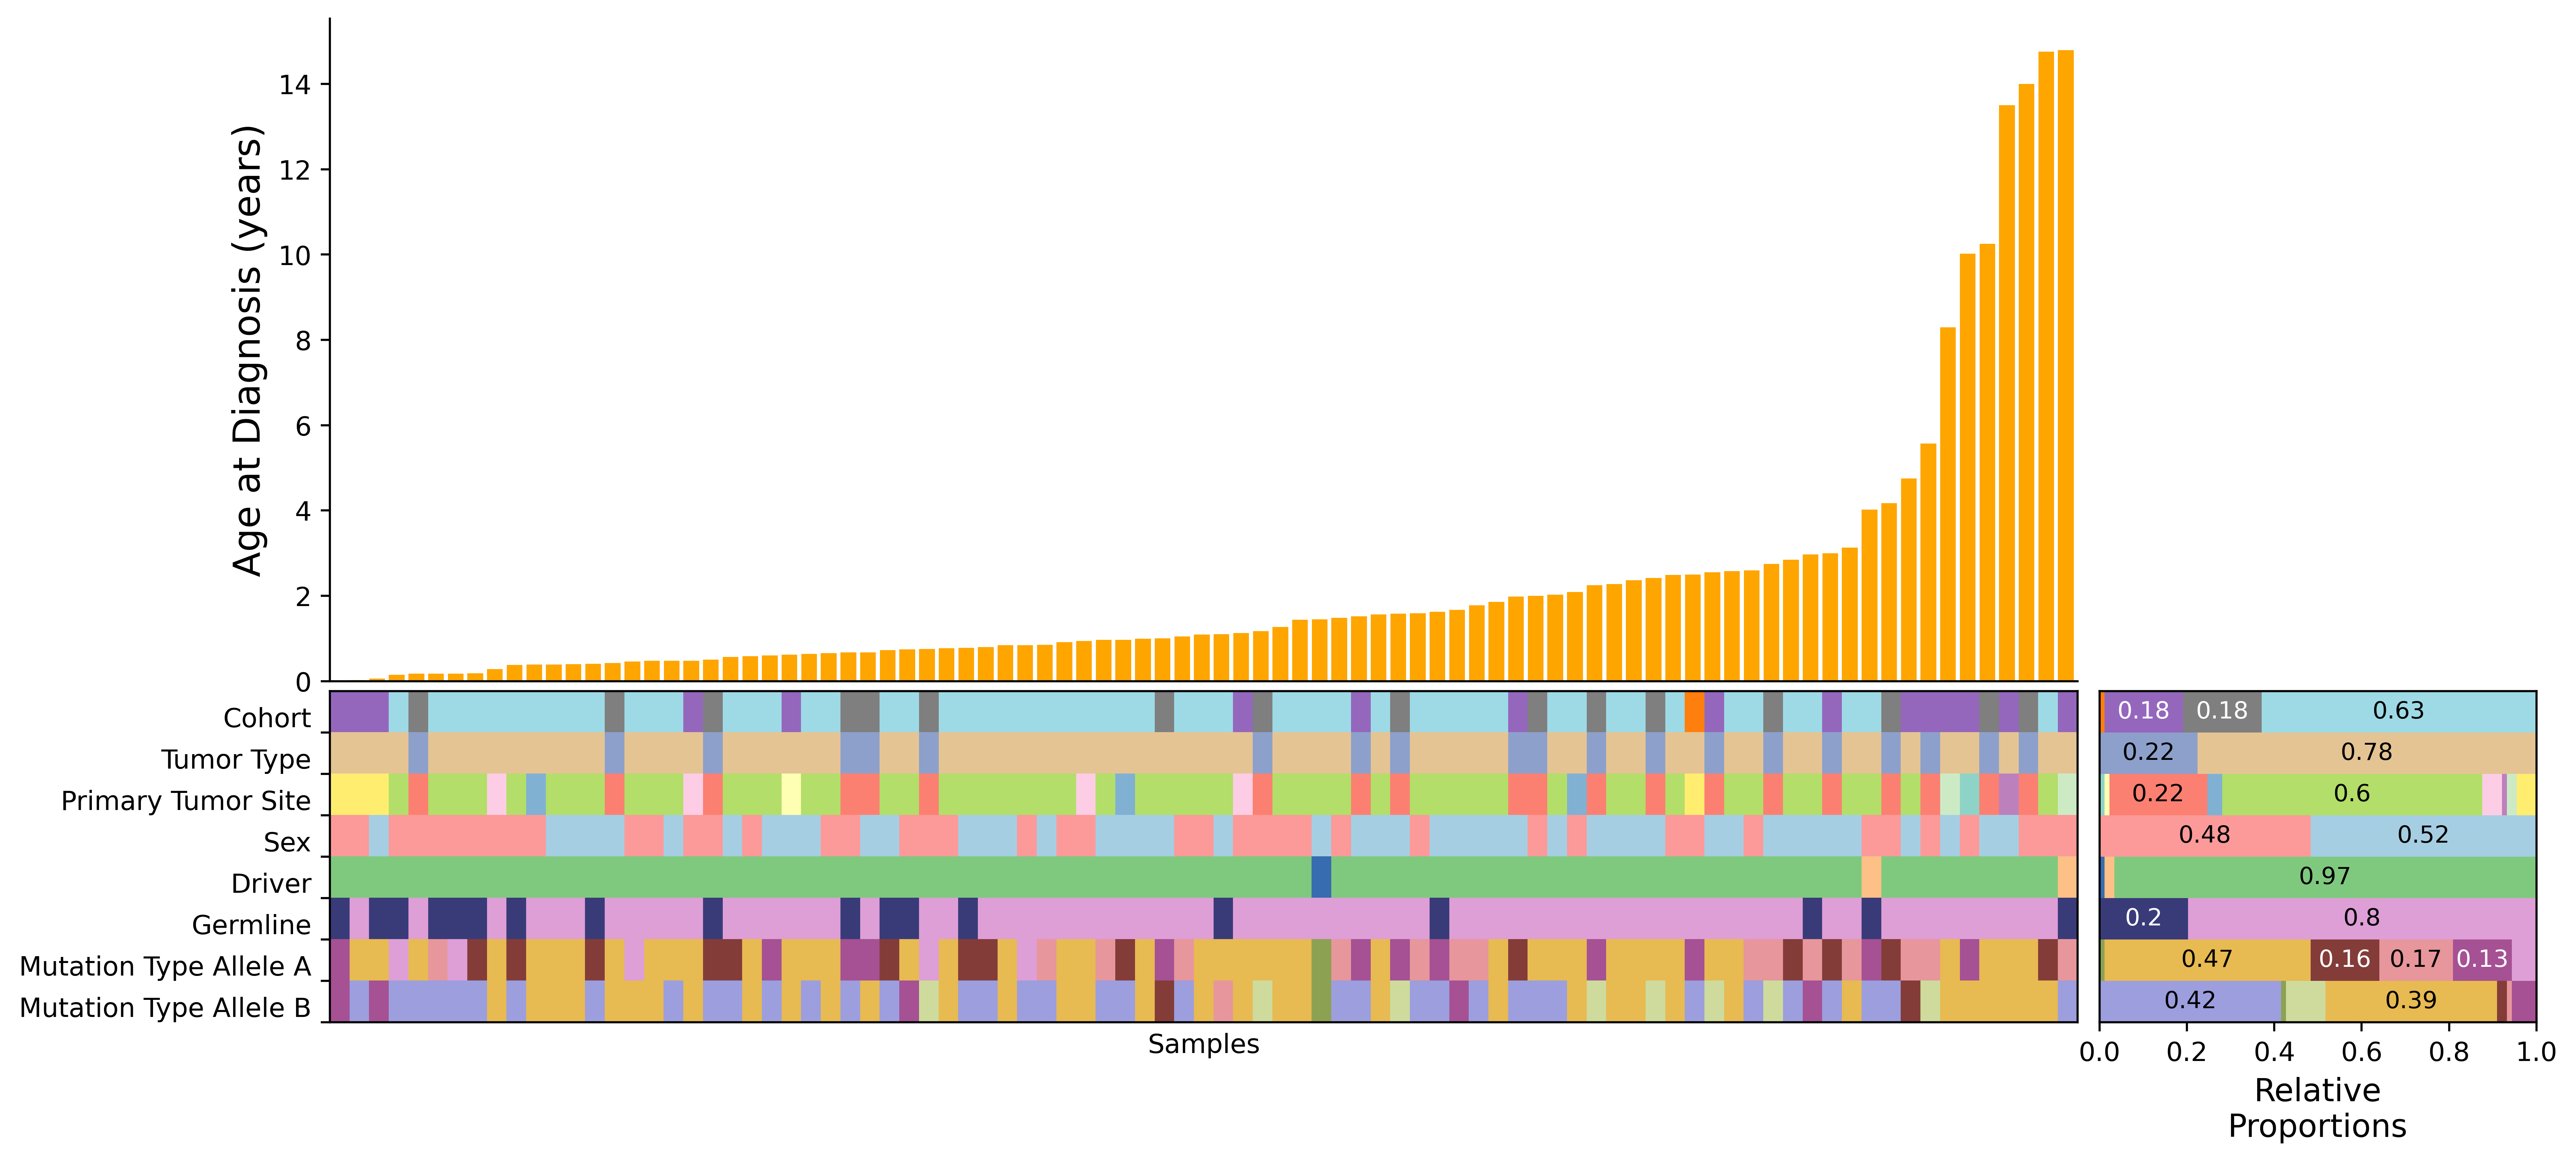

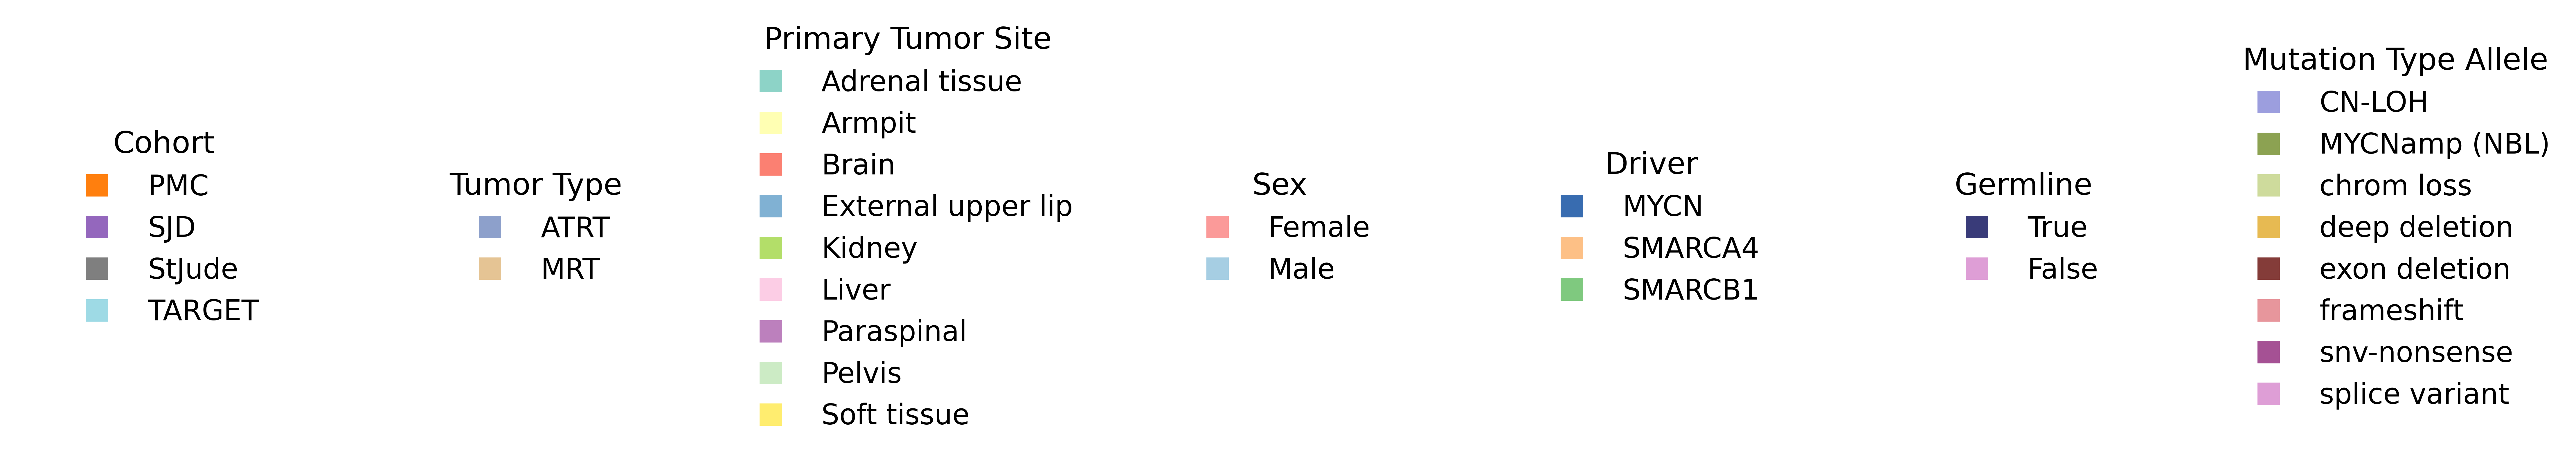

In [53]:
# Heatmap with samples as rows and clinical features as columns
# Select relevant clinical features (adjust as needed)
features = [ 'PATIENT','PATIENT2','COHORT','TUMOR_TYPE','PRY_TUMOR_SITE','SEX','SYMBOL','origin_a1','origin_a2','mut_type_a1','mut_type_a2','AGE_DIAGNOSIS']
features_label_dict = {'COHORT':'Cohort','TUMOR_TYPE':'Tumor Type','PRY_TUMOR_SITE':'Primary Tumor Site','SEX':'Sex',
                       'SYMBOL':'Driver','origin_a1':'Germline','origin_a2':'Origin Allele B',
                       'mut_type_a1':'Mutation Type Allele A','mut_type_a2':'Mutation Type Allele B',
                       'AGE_DIAGNOSIS':'Age at Diagnosis (Years)'}
features_label_dict2 = {'COHORT':'Cohort','TUMOR_TYPE':'Tumor Type','PRY_TUMOR_SITE':'Primary Tumor Site','SEX':'Sex',
                       'SYMBOL':'Driver','origin_a1':'Origin Allele','origin_a2':'Origin Allele',
                       'mut_type_a1':'Mutation Type Allele','mut_type_a2':'Mutation Type Allele',
                       'AGE_DIAGNOSIS':'Age at Diagnosis (Years)'}
# Creating a copy of the original dataframe before encoding, for the stacked bar chart
heatmap_df = merged_df[features].drop_duplicates().copy()
heatmap_df_original = heatmap_df.copy()

# Sort by AGE_DIAGNOSIS in increasing order
heatmap_df['AGE_DIAGNOSIS'] = heatmap_df['AGE_DIAGNOSIS'].astype(float)
heatmap_df = heatmap_df.sort_values('AGE_DIAGNOSIS', ascending=True)

# Encode categorical features numerically for visualization
cat_features = [f for f in features if f not in ['AGE_DIAGNOSIS','PATIENT','PATIENT2','origin_a2']]

label_encoders = {}
for col in [c for c in cat_features if c not in ['mut_type_a1','mut_type_a2','origin_a1','origin_a2']]:
    le = LabelEncoder()
    heatmap_df[col] = le.fit_transform(heatmap_df[col].astype(str))
    label_encoders[col] = le

# Handle mut_type_a1 and mut_type_a2 separately and first
mut_cols = ['mut_type_a1', 'mut_type_a2']
combined_values = pd.concat([heatmap_df[col] for col in mut_cols]).unique()
le_mut = LabelEncoder()
le_mut.fit(combined_values.astype(str))
label_encoders['mut_type'] = le_mut
heatmap_df['mut_type_a1'] = le_mut.transform(heatmap_df['mut_type_a1'].astype(str))
heatmap_df['mut_type_a2'] = le_mut.transform(heatmap_df['mut_type_a2'].astype(str))

# Combine unique values from both columns
origin_values = pd.concat([heatmap_df['origin_a1'], heatmap_df['origin_a2']]).astype(str).unique()
origin_le = LabelEncoder()
origin_le.fit(origin_values)
# Apply the same encoder to both columns
heatmap_df['origin_a1'] = origin_le.transform(heatmap_df['origin_a1'].astype(str))
heatmap_df['origin_a2'] = origin_le.transform(heatmap_df['origin_a2'].astype(str))
label_encoders['origin'] = origin_le


# Restore custom coloring for each feature
feature_colormaps = {}

# Assign a unique colormap to each categorical feature for maximum differentiation
colormap_dict = {
    'COHORT': 'tab20',
    'TUMOR_TYPE': 'Set2',
    'PRY_TUMOR_SITE': 'Set3',
    'SEX': 'Paired',
    'SYMBOL': 'Accent',
    'origin': 'tab20b',
    'mut_type': 'tab20b',
}

for col in [c for c in cat_features if c not in ['mut_type_a1','mut_type_a2','origin_a1','origin_a2']]:
    n_cats = len(heatmap_df[col].unique())
    cmap_name = colormap_dict.get(col, 'Spectral')
    cmap = plt.get_cmap(cmap_name)
    if col == 'COHORT':
        lim_cmap1 = 0.1
        lim_cmap2 = 1
    elif col == 'TUMOR_TYPE':
        lim_cmap1 = 0.3
        lim_cmap2 = 0.8
    elif col == 'SEX':
        lim_cmap1 = 0.4
        lim_cmap2 = 0
    elif col == 'SYMBOL':
        lim_cmap1 = 0.5
        lim_cmap2 = 0
    else:
        lim_cmap1 = 0
        lim_cmap2 = 1
    colors = cmap(np.linspace(lim_cmap1, lim_cmap2, n_cats))
    feature_colormaps[col] = ListedColormap(colors)

col ='origin'
n_cats = len(origin_values)
cmap_name = colormap_dict.get(col, 'Spectral')
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0, 1, n_cats))
feature_colormaps[col] = ListedColormap(colors)

col ='mut_type'
n_cats = len(combined_values)
cmap_name = colormap_dict.get(col, 'Spectral')
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.15, 1, n_cats))
feature_colormaps[col] = ListedColormap(colors)


# Create the main figure and gridspec
fig = plt.figure(figsize=(15,7), dpi=500)
# Adjusted gridspec for a two-row, two-column layout
# Row 0: Heatmap (ax0) and Age Bar Plot (ax1)
# Row 1: Stacked Bar Plot (ax2), spanning both columns
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[16, 4], hspace=0.02, wspace=0.02)

# Vertical barplot for AGE_DIAGNOSIS, now to the right of the heatmap
ax0 = fig.add_subplot(gs[0,0])
# h_df = heatmap_df.sort_values('AGE_DIAGNOSIS',ascending=False)
ax0.bar(range(len(heatmap_df)), heatmap_df['AGE_DIAGNOSIS'], color='orange', width=0.8, align='edge')
ax0.set_ylabel('Age at Diagnosis (years)',size=14)
ax0.set_xticks(range(len(heatmap_df)))
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.set_xlim(0, len(heatmap_df))

# For barplot axis (ax0), hide x-tick labels (for shared y-axis)
ax0.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Heatmap subplot
ax1 = fig.add_subplot(gs[1,0],sharex=ax0)
n_rows = heatmap_df.shape[0]
n_cols = len(cat_features)

# Heatmap with categorical features, using a loop to apply custom coloring
for i, col in enumerate(cat_features):

    # Get the data for the current column
    data = heatmap_df[col].values

    #Get the specific colormap for the current feature
    if col in ['mut_type_a1','mut_type_a2']:
        current_cmap = feature_colormaps['mut_type']
        # Use the combined unique values for normalization
        unique_vals_for_norm = combined_values
    elif col in ['origin_a1','origin_a2']:
        current_cmap = feature_colormaps['origin']
        # Use the combined unique values for normalization
        unique_vals_for_norm = origin_values
    else:
        current_cmap = feature_colormaps[col]
        # Use the unique values of the current column
        unique_vals_for_norm = np.sort(np.unique(data))

    # Create the correct boundaries for the colormap
    boundaries = np.arange(len(unique_vals_for_norm)+1) -0.5

    # Create the normalization object
    norm = mcolors.BoundaryNorm(boundaries=boundaries, ncolors=len(current_cmap.colors))

    # Plot the column as an individual image on the same axes
    im = ax1.imshow(data[np.newaxis, :], aspect='auto', cmap=current_cmap, norm=norm,
                    extent=[0, n_rows, n_cols - 1 - i, n_cols - i],
                    origin='upper')

# Set ticks and labels: center labels below each column, move x-axis labels up using labelpad
ax1.set_yticks([i for i in range(n_cols)])
cat_features_reversed = cat_features.reverse()
ax1.set_yticklabels([features_label_dict[f] for f in cat_features], fontsize=10, rotation=0, ha='right', va='bottom')
# ax1.set_yticklabels([features_label_dict[f] for f in cat_features], rotation=0)
ax1.set_xlabel('Samples')

# Set y-tick labels for heatmap axis (ax0) to PATIENT names
# ax1.set_xticks(np.arange(n_rows))
ax1.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
# sorted_df = heatmap_df.sort_values('AGE_DIAGNOSIS',ascending=False)
ax1.set_xticklabels([], fontsize=8,fontdict={'verticalalignment':'top','horizontalalignment':'left'},rotation=90)


# --- Stacked Bar Plot Section ---
# Stacked bar plot subplot, now spanning the bottom row
ax2 = fig.add_subplot(gs[1,1],sharey=ax1)
# ax2.set_title('Relative Proportions of Categorical Features', fontsize=16)

x_offset = 0.5
n_features = len(cat_features)

# The new logic loops through all categorical features to align with the heatmap
for i, col in enumerate(cat_features):
    # Determine the correct LabelEncoder and colormap for the current column
    if 'origin' in col:
        le = label_encoders['origin']
        cmap = feature_colormaps['origin']
    elif 'mut_type' in col:
        le = label_encoders['mut_type']
        cmap = feature_colormaps['mut_type']
    else:
        le = label_encoders[col]
        cmap = feature_colormaps[col]
        
    # Get the value counts for the current column
    counts = heatmap_df_original[col].value_counts(normalize=True).sort_index()
    left = 0
    
     # Invert the row order
    inverted_index = (n_features - 1 - i) + x_offset
    
    # Iterate through the categories and plot each segment of the stacked bar
    labels_list = list(le.classes_)
    for j, cat_name in enumerate(labels_list):
        if cat_name in counts:
            proportion = counts[cat_name]
            # Use the correct color index from the LabelEncoder
            color_index = le.transform([cat_name])[0]
            color = cmap.colors[color_index % len(cmap.colors)]
            ax2.barh(i+x_offset, proportion, left=left, color=color, height=1)
            if proportion >0.1:
                if cat_name in ['germline','exon deletion','StJude','SJD','snv-nonsense','CNLOH']:
                    color = 'white'
                else:
                    color = 'k'
                ax2.text(left+(proportion/2),i+x_offset, s=str(round(proportion,2)),size=9,ha='center',va='center',color=color)
            left += proportion

# ax2.set_yticks([i + x_offset for i in range(len(cat_features))])
ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
ax2.set_xlabel('Relative\nProportions', size=12)
ax2.set_xlim(0, 1)
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
ax2.set_ylim(bottom=0,top=len(cat_features))
# ax2.yaxis.set_label_position("right")
# ax2.yaxis.tick_right()

fig.tight_layout()
plt.savefig('plots/heatmap_and_bars.svg', bbox_inches='tight',format='svg')

# --- Unified Legend layout for origin and mutation type ---
legend_fig, legend_axs = plt.subplots(1, len(cat_features)-1, figsize=(18, 3), dpi=500, gridspec_kw={'width_ratios': [1]*(len(cat_features)-1)})

# Define unified pairs
unified_pairs = {
    'Origin Allele': ['origin_a1', 'origin_a2'],
    'Mutation Type Allele': ['mut_type_a1', 'mut_type_a2']
}

idx = 0
# Add legends for the remaining features
for col in [c for c in reversed(cat_features) if c not in sum(unified_pairs.values(), [])]:
    cmap = feature_colormaps[col]
    n_cats = len(heatmap_df[col].unique())
    labels = list(label_encoders[col].classes_)
    handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cmap.colors[j % len(cmap.colors)], markersize=12) for j in range(n_cats)]
    legend_axs[idx].axis('off')
    legend_title = features_label_dict2.get(col, col)
    legend_axs[idx].legend(handles, labels, title=legend_title, loc='center', bbox_to_anchor=(0.5, 0.5), ncol=1, fontsize=14, title_fontsize=15, frameon=False)
    idx += 1

title = 'Germline'
col = 'origin'
cmap = feature_colormaps[col]
labels = list(label_encoders[col].classes_)
labels_dict = {'germline':True,'somatic':False}
labels = [labels_dict[label] for label in labels]
print(labels)
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cmap.colors[j % len(cmap.colors)], markersize=12) for j in range(len(labels))]
legend_axs[idx].axis('off')
legend_axs[idx].legend(handles, labels, title=title, loc='center', bbox_to_anchor=(0.5, 0.5), ncol=1, fontsize=14, title_fontsize=15, frameon=False)
idx += 1

title = 'Mutation Type Allele'
col = 'mut_type'
labels = list(label_encoders[col].classes_)
cmap = feature_colormaps[col]
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cmap.colors[j % len(cmap.colors)], markersize=12) for j in range(len(labels))]
legend_axs[idx].axis('off')
legend_axs[idx].legend(handles, labels, title=title, loc='center', bbox_to_anchor=(0.5, 0.5), ncol=1, fontsize=14, title_fontsize=15, frameon=False)
idx += 1

legend_fig.tight_layout(pad=1.0)
plt.savefig('plots/heatmap_and_bars_legend.svg', bbox_inches='tight',format='svg')

In [54]:
df = merged_df[['COHORT','SAMPLE']].drop_duplicates().groupby('COHORT').count()
total = df.sum()[0]
df['%'] = round(df['SAMPLE']/total*100,1)
display(df)
df.sum()

/tmp/ipykernel_1162515/3142136271.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,SAMPLE,%
COHORT,,
PMC,4,4.1
SJD,22,22.4
StJude,16,16.3
TARGET,56,57.1


SAMPLE    98.0
%         99.9
dtype: float64

In [55]:
merged_df.columns

Index(['PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT', 'PATIENT2', 'TUMOR', 'SAMPLE', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples', 'allele1', 'allele2', 'origin_a1', 'origin_a2',
       'germline', '_merge', 'mut_type_a1', 'mut_type_a2'],
      dtype='object')

In [56]:
for col in ['COHORT','TUMOR_TYPE','PRY_TUMOR_SITE','SEX','mut_type_a1','CNLOH','SYMBOL','germline','mut_type_a1','mut_type_a2']:
    df = merged_df[['PATIENT']+[col]].drop_duplicates().groupby(col).count()
    total = df.sum()[0]
    df['%'] = round(df['PATIENT']/total*100,1)
    display(df)

/tmp/ipykernel_1162515/458888219.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,%
COHORT,,
PMC,1,1.1
SJD,16,18.0
StJude,16,18.0
TARGET,56,62.9


/tmp/ipykernel_1162515/458888219.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,%
TUMOR_TYPE,,
ATRT,20,22.5
MRT,69,77.5


/tmp/ipykernel_1162515/458888219.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


...

,PATIENT,%
germline,,
False,71,79.8
True,18,20.2


/tmp/ipykernel_1162515/458888219.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,%
mut_type_a1,,
MYCNamp (NBL),1,1.1
deep deletion,42,47.2
exon deletion,14,15.7
frameshift,15,16.9
snv-nonsense,12,13.5
splice variant,5,5.6


/tmp/ipykernel_1162515/458888219.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,%
mut_type_a2,,
CN-LOH,37,41.6
MYCNamp (NBL),1,1.1
chrom loss,8,9.0
deep deletion,35,39.3
exon deletion,2,2.2
frameshift,1,1.1
snv-nonsense,5,5.6


In [57]:
df = merged_df[['PATIENT','mut_type_a1','mut_type_a2']].drop_duplicates().groupby(['mut_type_a1','mut_type_a2']).count()
total = df.sum()[0]
df['%'] = round(df['PATIENT']/total*100,1)
display(df)

/tmp/ipykernel_1162515/381017964.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
mut_type_a1    mut_type_a2                 
MYCNamp (NBL)  MYCNamp (NBL)        1   1.1
deep deletion  CN-LOH               6   6.7
               chrom loss           3   3.4
               deep deletion       30  33.7
               frameshift           1   1.1
               snv-nonsense         2   2.2
exon deletion  CN-LOH              13  14.6
               deep deletion        1   1.1
frameshift     CN-LOH               9  10.1
               chrom loss           2   2.2
               deep deletion        1   1.1
               exon deletion        1   1.1
               snv-nonsense         2   2.2
snv-nonsense   CN-LOH               6   6.7
               chrom loss           2   2.2
               deep deletion        2   2.2
               exon deletion        1   1.1
               snv-nonsense         1   1.1
splice variant CN-LOH               3   3.4
               chrom loss           1   1.1
               deep deletion        1   1.1

In [58]:
df = merged_df[['PATIENT','mut_type_a2','mut_type_a1','germline']].drop_duplicates().groupby(['mut_type_a2','mut_type_a1','germline']).count()
total = df.sum()[0]
df['%'] = round(df['PATIENT']/total*100,1)
display(df)

/tmp/ipykernel_1162515/1196188499.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
mut_type_a2   mut_type_a1    germline               
CN-LOH        deep deletion  False           6   6.7
              exon deletion  False           7   7.9
                             True            6   6.7
              frameshift     False           7   7.9
                             True            2   2.2
              snv-nonsense   False           3   3.4
                             True            3   3.4
              splice variant False           1   1.1
                             True            2   2.2
MYCNamp (NBL) MYCNamp (NBL)  False           1   1.1
chrom loss    deep deletion  False           3   3.4
              frameshift     False           2   2.2
              snv-nonsense   False           2   2.2
              splice variant False           1   1.1
deep deletion deep deletion  False          30  33.7
              exon deletion  False           1   1.1
              frameshift     False           1   1.1
              snv-nonsense   False           2   2.2
              splice variant False           1   1.1
exon deletion frameshift     False           1   1.1
              snv-nonsense   False           1   1.1
frameshift    deep deletion  True            1   1.1
snv-nonsense  deep deletion  True            2   2.2
              frameshift     False           1   1.1
                             True            1   1.1
              snv-nonsense   True            1   1.1

In [59]:
for col in ['mut_type_a1','mut_type_a2']:
    df = merged_df[['PATIENT','mut_type_a1','mut_type_a2','germline']].drop_duplicates().groupby([col]).count()
    total = df.sum()[0]
    df['%'] = round(df['PATIENT']/total*100,1)
    display(df)

/tmp/ipykernel_1162515/4195530379.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,mut_type_a2,germline,%
mut_type_a1,,,,
MYCNamp (NBL),1,1,1,1.1
deep deletion,42,42,42,47.2
exon deletion,14,14,14,15.7
frameshift,15,15,15,16.9
snv-nonsense,12,12,12,13.5
splice variant,5,5,5,5.6


/tmp/ipykernel_1162515/4195530379.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


,PATIENT,mut_type_a1,germline,%
mut_type_a2,,,,
CN-LOH,37,37,37,41.6
MYCNamp (NBL),1,1,1,1.1
chrom loss,8,8,8,9.0
deep deletion,35,35,35,39.3
exon deletion,2,2,2,2.2
frameshift,1,1,1,1.1
snv-nonsense,5,5,5,5.6


In [60]:
for col in ['TUMOR_TYPE','PRY_TUMOR_SITE','SEX','mut_type_a1','CNLOH']:
    df = merged_df[['PATIENT','COHORT']+[col]].drop_duplicates().groupby(['COHORT',col]).count()
    total = df.sum()[0]
    df['%'] = round(df['PATIENT']/total*100,1)
    display(df)

/tmp/ipykernel_1162515/1382811296.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
COHORT TUMOR_TYPE               
PMC    MRT               1   1.1
SJD    ATRT              5   5.6
       MRT              11  12.4
StJude ATRT             15  16.9
       MRT               1   1.1
TARGET MRT              56  62.9

/tmp/ipykernel_1162515/1382811296.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
COHORT PRY_TUMOR_SITE                   
PMC    Soft tissue               1   1.1
SJD    Adrenal tissue            1   1.1
       Armpit                    1   1.1
       Brain                     5   5.6
       Kidney                    1   1.1
       Liver                     2   2.2
       Paraspinal                1   1.1
       Pelvis                    2   2.2
       Soft tissue               3   3.4
StJude Brain                    15  16.9
       Kidney                    1   1.1
TARGET External upper lip        3   3.4
       Kidney                   51  57.3
       Liver                     2   2.2

/tmp/ipykernel_1162515/1382811296.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
COHORT SEX                  
PMC    Female        1   1.1
SJD    Female        7   7.9
       Male          9  10.1
StJude Female        8   9.0
       Male          8   9.0
TARGET Female       27  30.3
       Male         29  32.6

/tmp/ipykernel_1162515/1382811296.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
COHORT mut_type_a1                  
PMC    snv-nonsense          1   1.1
SJD    deep deletion         8   9.0
       exon deletion         2   2.2
       frameshift            3   3.4
       snv-nonsense          3   3.4
StJude deep deletion         7   7.9
       exon deletion         2   2.2
       frameshift            1   1.1
       snv-nonsense          5   5.6
       splice variant        1   1.1
TARGET MYCNamp (NBL)         1   1.1
       deep deletion        27  30.3
       exon deletion        10  11.2
       frameshift           11  12.4
       snv-nonsense          3   3.4
       splice variant        4   4.5

/tmp/ipykernel_1162515/1382811296.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = df.sum()[0]


PATIENT     %
COHORT CNLOH               
PMC    True         1   1.1
SJD    False       11  12.4
       True         5   5.6
StJude False       11  12.4
       True         5   5.6
TARGET False       30  33.7
       True        26  29.2

In [54]:
merged_df[merged_df['PATIENT2']=='PT44']

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
47,PADWRZ,1.049315,Female,MRT,Kidney,TARGET,PT44,tumor1,PADWRZ-01A_vs_PADWRZ-10A,SMARCB1,...,NaN,NaN,V57fs,CNLOH,somatic,somatic,False,both,frameshift,CN-LOH


In [55]:
merged_df.groupby('CNLOH').count()

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
CNLOH,,,,,,,,,,,,,,,,,,,,,
False,65,65,65,65,65,65,65,65,65,65,...,3,0,65,65,65,65,65,65,65,65
True,42,42,42,42,42,42,42,42,42,42,...,0,0,42,42,42,42,42,42,42,42


In [56]:
merged_df[['PATIENT','mut_type_a1','mut_type_a2','origin_a1','origin_a2']].drop_duplicates().groupby(['origin_a1','origin_a2','mut_type_a1','mut_type_a2',]).count()

PATIENT
origin_a1 origin_a2 mut_type_a1    mut_type_a2           
germline  germline  frameshift     snv-nonsense         1
          somatic   deep deletion  frameshift           1
                                   snv-nonsense         2
                    exon deletion  CN-LOH               6
                    frameshift     CN-LOH               2
                    snv-nonsense   CN-LOH               3
                                   snv-nonsense         1
                    splice variant CN-LOH               2
somatic   somatic   MYCNamp (NBL)  MYCNamp (NBL)        1
                    deep deletion  CN-LOH               6
                                   chrom loss           3
                                   deep deletion       30
                    exon deletion  CN-LOH               7
                                   deep deletion        1
                    frameshift     CN-LOH               7
                                   chrom loss           2
                                   deep deletion        1
                                   exon deletion        1
                                   snv-nonsense         1
                    snv-nonsense   CN-LOH               3
                                   chrom loss           2
                                   deep deletion        2
                                   exon deletion        1
                    splice variant CN-LOH               1
                                   chrom loss           1
                                   deep deletion        1

In [57]:
small_variants = ['frameshift','snv-nonsense','exon deletion','splice variant']
merged_df[['PATIENT','mut_type_a1','mut_type_a2','origin_a1','origin_a2']][merged_df['mut_type_a1'].isin(small_variants)|merged_df['mut_type_a2'].isin(small_variants)].drop_duplicates().groupby(['origin_a1','origin_a2','mut_type_a1','mut_type_a2',]).count()

PATIENT
origin_a1 origin_a2 mut_type_a1    mut_type_a2           
germline  germline  frameshift     snv-nonsense         1
          somatic   deep deletion  frameshift           1
                                   snv-nonsense         2
                    exon deletion  CN-LOH               6
                    frameshift     CN-LOH               2
                    snv-nonsense   CN-LOH               3
                                   snv-nonsense         1
                    splice variant CN-LOH               2
somatic   somatic   exon deletion  CN-LOH               7
                                   deep deletion        1
                    frameshift     CN-LOH               7
                                   chrom loss           2
                                   deep deletion        1
                                   exon deletion        1
                                   snv-nonsense         1
                    snv-nonsense   CN-LOH               3
                                   chrom loss           2
                                   deep deletion        2
                                   exon deletion        1
                    splice variant CN-LOH               1
                                   chrom loss           1
                                   deep deletion        1

In [58]:
mut_type = 'deep deletion'
print('total pts',len(merged_df['PATIENT'].drop_duplicates()))
merged_df[['PATIENT','mut_type_a1','mut_type_a2','origin_a1','origin_a2']][(merged_df['mut_type_a1']==mut_type)|(merged_df['mut_type_a2']==mut_type)].drop_duplicates().groupby(['origin_a1','origin_a2','mut_type_a1','mut_type_a2',]).count()

total pts 89


PATIENT
origin_a1 origin_a2 mut_type_a1    mut_type_a2           
germline  somatic   deep deletion  frameshift           1
                                   snv-nonsense         2
somatic   somatic   deep deletion  CN-LOH               6
                                   chrom loss           3
                                   deep deletion       30
                    exon deletion  deep deletion        1
                    frameshift     deep deletion        1
                    snv-nonsense   deep deletion        2
                    splice variant deep deletion        1

In [61]:
print('deep deletion in both alleles',round(30/88,2))
print('exon deletion',round(16/88,2))
print('frameshift',round(16/88,2))
print('snv-nonsense',round(15/88,2))
print('splice variant',round(5/88,2))
print('CNLOH',round(36/88,2))

deep deletion in both alleles 0.34
exon deletion 0.18
frameshift 0.18
snv-nonsense 0.17
splice variant 0.06
CNLOH 0.41


In [60]:
merged_df[['PATIENT','PRY_TUMOR_SITE']].drop_duplicates().groupby('PRY_TUMOR_SITE').count()

,PATIENT
PRY_TUMOR_SITE,
Adrenal tissue,1
Armpit,1
Brain,20
External upper lip,3
Kidney,53
Liver,4
Paraspinal,1
Pelvis,2
Soft tissue,4


In [61]:
merged_df[merged_df['PRY_TUMOR_SITE']=='Paraspinal']

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
99,pt5,13.5,Male,MRT,Paraspinal,SJD,PT86,tumor1,AX4918_vs_AX4897,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion
100,pt5,13.5,Male,MRT,Paraspinal,SJD,PT86,tumor2,AX4944_vs_AX489,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion


In [62]:
merged_df[merged_df['PATIENT'].isin(['pt1','pt5'])]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
94,pt1,8.29,Male,MRT,Pelvis,SJD,PT83,tumor1,AX4912_vs_AX4894,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion
95,pt1,8.29,Male,MRT,Pelvis,SJD,PT83,tumor2,AX4937_vs_AX4894,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion
99,pt5,13.50,Male,MRT,Paraspinal,SJD,PT86,tumor1,AX4918_vs_AX4897,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion
100,pt5,13.50,Male,MRT,Paraspinal,SJD,PT86,tumor2,AX4944_vs_AX489,SMARCB1,...,NaN,NaN,del,del,somatic,somatic,False,both,deep deletion,deep deletion


## Prepare Supplementary table

In [62]:
final_df = merged_df.copy()
final_df = final_df.rename(columns={'PATIENT':'ORIGINAL_CASE_ID',
                                    'PATIENT2':'CASE_ID',
                                    'SYMBOL':'DRIVER',
                                    'SMARCB1 status':'DRIVER_MUTS',
                                    'germline':'GERMLINE',
                                    'allele1':'ALLELE1',
                                    'allele2':'ALLELE2',
                                    'mut_type_a1':'MUT_TYPE_A1',
                                    'mut_type_a2':'MUT_TYPE_A2',
                                    'chr22_del_a1':'EXON_DEL_A1',
                                    'chr22_del_a2':'EXON_DEL_A2'})
final_df

,ORIGINAL_CASE_ID,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,CASE_ID,TUMOR,SAMPLE,DRIVER,...,EXON_DEL_A2,Excluded_samples,ALLELE1,ALLELE2,origin_a1,origin_a2,GERMLINE,_merge,MUT_TYPE_A1,MUT_TYPE_A2
0,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,NaN,NaN,I109X germline,V57X,germline,somatic,True,both,snv-nonsense,snv-nonsense
1,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,NaN,NaN,I109X germline,V57X,germline,somatic,True,both,snv-nonsense,snv-nonsense
2,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,NaN,NaN,I109X germline,V57X,germline,somatic,True,both,snv-nonsense,snv-nonsense
3,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,NaN,NaN,I109X germline,V57X,germline,somatic,True,both,snv-nonsense,snv-nonsense
4,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02,tumor1,AX4916_vs_AX4896,SMARCB1,...,NaN,NaN,del,CNLOH,somatic,somatic,False,both,deep deletion,CN-LOH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both,exon deletion,deep deletion
103,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both,exon deletion,deep deletion
104,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both,exon deletion,deep deletion
105,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both,exon deletion,deep deletion


In [63]:
final_df.columns

Index(['ORIGINAL_CASE_ID', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE',
       'PRY_TUMOR_SITE', 'COHORT', 'CASE_ID', 'TUMOR', 'SAMPLE', 'DRIVER',
       'variant_type', 'Consequence', 'aa_change', 'mut', 'Damaging', 'origin',
       'VAF', 'CNA', 'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr',
       'germ_som', 'CNLOH', 'DRIVER_MUTS', 'EXON_DEL_A1', 'EXON_DEL_A2',
       'Excluded_samples', 'ALLELE1', 'ALLELE2', 'origin_a1', 'origin_a2',
       'GERMLINE', '_merge', 'MUT_TYPE_A1', 'MUT_TYPE_A2'],
      dtype='object')

In [64]:
final_df[['CASE_ID','mut']].drop_duplicates()

,CASE_ID,mut
0,PT01,chr22:23791833:G>-
1,PT01,chr22:23793678->G
4,PT02,NaN
6,PT03,chr22:23791774:->ATGTTCC
7,PT04,chr22:23793536:CCAGTGATGTTTGTCTGTTACAGATCACGGA...
...,...,...
98,PT85,NaN
99,PT86,NaN
101,PT87,NaN
102,PT88,NaN


In [65]:
cols = ['CASE_ID','ORIGINAL_CASE_ID','COHORT', 'AGE_DIAGNOSIS','TUMOR_TYPE',
        'PRY_TUMOR_SITE','SEX','DRIVER','GERMLINE','ALLELE1','ALLELE2',
        'MUT_TYPE_A1','MUT_TYPE_A2','EXON_DEL_A1','EXON_DEL_A2']
final_df = final_df[cols].drop_duplicates()
final_df

,CASE_ID,ORIGINAL_CASE_ID,COHORT,AGE_DIAGNOSIS,TUMOR_TYPE,PRY_TUMOR_SITE,SEX,DRIVER,GERMLINE,ALLELE1,ALLELE2,MUT_TYPE_A1,MUT_TYPE_A2,EXON_DEL_A1,EXON_DEL_A2
0,PT01,pt18,SJD,0.010000,MRT,Soft tissue,Female,SMARCB1,True,I109X germline,V57X,snv-nonsense,snv-nonsense,NaN,NaN
4,PT02,pt4,SJD,0.020000,MRT,Soft tissue,Female,SMARCB1,False,del,CNLOH,deep deletion,CN-LOH,NaN,NaN
6,PT03,pt13,SJD,0.060000,MRT,Soft tissue,Male,SMARCB1,True,del germline,-37-38MFX,deep deletion,snv-nonsense,NaN,NaN
7,PT04,PAUDPV,TARGET,0.147945,MRT,Kidney,Female,SMARCB1,True,splice variant germline,CNLOH,splice variant,CN-LOH,NaN,NaN
8,PT05,SJ032417,StJude,0.170000,ATRT,Brain,Female,SMARCB1,False,del,CNLOH,deep deletion,CN-LOH,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,PT85,SJ030581,StJude,10.250000,ATRT,Brain,Male,SMARCB1,False,del,del,deep deletion,deep deletion,NaN,NaN
99,PT86,pt5,SJD,13.500000,MRT,Paraspinal,Male,SMARCB1,False,del,del,deep deletion,deep deletion,NaN,NaN
101,PT87,SJ032393,StJude,14.000000,ATRT,Brain,Female,SMARCB1,False,del,del,deep deletion,deep deletion,NaN,NaN
102,PT88,PAUEKW,TARGET,14.756164,MRT,Kidney,Female,SMARCB1,False,exon1-5-del,del,exon deletion,deep deletion,23776542-23809445,NaN


In [66]:
final_df.to_csv('tables/Supplementary_Table1.tsv',sep='\t',index=None)